In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.chdir('/home/jovyan/kuratov/data/test_time_gd/')

import torch

from transformers import GPT2Config, GPT2LMHeadModel

from kv_dataset_utils import create_tokenizer

from grad_memgpt import GradMemGPT

In [2]:
import json
from pathlib import Path

checkpoint = 'checkpoint-95500'

exp_path = Path('/home/jovyan/kuratov/data/test_time_gd/runs/N2-K4V4-S1(16-32)_1M/gradmemgpt_L4H4D128_mem8_K5_ilr1.0_grad_second_bs_64_lr_1e-04/run_1/')
# checkpoint = 'checkpoint-1500'
# exp_path = Path('/home/jovyan/kuratov/data/test_time_gd/runs/N0-S1(4-4)_1M/gradmemgpt_L4H4D128_mem8_K1_ilr1.0_grad_second_bs_64_lr_1e-04/run_1')

exp_config = exp_path / 'config.json'
exp_config = json.load(open(exp_config))['cli_args']

exp_config

{'exp_path': './runs/N2-K4V4-S1(16-32)_1M/gradmemgpt_L4H4D128_mem8_K5_ilr1.0_grad_second_bs_64_lr_1e-04/run_1',
 'per_device_batch_size': 64,
 'data_path': './data/N2-K4V4-S1(16-32)_1M',
 'gradient_accumulation_steps': 1,
 'total_batch_size': 64,
 'metric_for_best_model': 'token_accuracy',
 'warmup_steps': 1000,
 'max_steps': 200000,
 'logging_steps': 500,
 'eval_steps': 500,
 'weight_decay': 0.0,
 'learning_rate': 0.0001,
 'lr_scheduler_type': 'constant_with_warmup',
 'early_stopping_patience': 500,
 'seed': 143,
 'n_layer': 4,
 'n_head': 4,
 'n_embd': 128,
 'n_mem_tokens': 8,
 'K': 5,
 'inner_lr': 1.0,
 'use_adam': False,
 'grad_mode': 'second'}

In [3]:
# create tokenizer
tokenizer = create_tokenizer()

# create model config
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = exp_config['n_layer']
config.n_head = exp_config['n_head']
config.n_embd = exp_config['n_embd']
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

# Create gradmemgpt model
model = GradMemGPT(config, n_mem_tokens=exp_config['n_mem_tokens'], K=exp_config['K'], lr=exp_config['inner_lr'],
                   use_adam=exp_config['use_adam'], grad_mode=exp_config['grad_mode'])

In [4]:
from safetensors.torch import load_model

load_model(model, exp_path / checkpoint / 'model.safetensors')
model.eval()
model.cuda()

GradMemGPT(
  (gpt): GPT2LMHeadModel(
    (transformer): GPT2Model(
      (wte): Embedding(128, 128)
      (wpe): Embedding(1024, 128)
      (drop): Dropout(p=0.1, inplace=False)
      (h): ModuleList(
        (0-3): 4 x GPT2Block(
          (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2Attention(
            (c_attn): Conv1D(nf=384, nx=128)
            (c_proj): Conv1D(nf=128, nx=128)
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D(nf=512, nx=128)
            (c_proj): Conv1D(nf=128, nx=512)
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (lm_head): Linear(in_features=128, out_features=128, bias=

In [5]:
with torch.no_grad():
    print(model.mem)

Parameter containing:
tensor([[-0.0030,  0.0105, -0.0010,  ..., -0.0192, -0.0211,  0.0109],
        [-0.0073, -0.0022, -0.0233,  ..., -0.0380,  0.0108, -0.0027],
        [ 0.0009,  0.0083, -0.0153,  ..., -0.0251, -0.0027,  0.0025],
        ...,
        [-0.0071, -0.0032, -0.0041,  ...,  0.0084,  0.0031, -0.0094],
        [-0.0025, -0.0087, -0.0301,  ..., -0.0101,  0.0039,  0.0069],
        [ 0.0005, -0.0060, -0.0225,  ..., -0.0154, -0.0178, -0.0276]],
       device='cuda:0', requires_grad=True)


In [7]:
import datasets
dataset = datasets.load_from_disk('./data/N2-K4V4-S1(16-32)_1M')['valid']
dataset[0]

{'context': 'q!aLA3:w5fz!5X!7gjy:l8fG!ywS|',
 'query': '?!7gjy:',
 'target': 'l8fG!|'}

In [33]:
from torch.utils.data import DataLoader

def collate_fn(batch, tokenizer):
    context = [item['context'] for item in batch]
    query = [item['query'] + item['target'] for item in batch]
    only_query = [item['query'] for item in batch]

    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=False,
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_input_ids = tokenizer(query, return_tensors="pt", add_special_tokens=False,
                                padding=True, pad_to_multiple_of=8).input_ids
    only_query_input_ids = tokenizer(only_query, return_tensors="pt", add_special_tokens=False,
                                padding=True,).input_ids
    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i, item in enumerate(batch):
        query_seq_len = len(item['query'])
        target_seq_len = len(item['target'])
        labels_mask[i, query_seq_len:query_seq_len+target_seq_len] = 1

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100
    return {
        # 'context_input_ids': context_input_ids,
        # 'query_input_ids': query_input_ids,
        'input_ids': {
            'context_input_ids': context_input_ids,
            'query_input_ids': query_input_ids,
            'only_query_input_ids': only_query_input_ids,
        },
        'labels': labels,
    }

def data_collator(batch):
    return collate_fn(batch, tokenizer)

dataloader = DataLoader(dataset, batch_size=1, collate_fn=data_collator, shuffle=True)

for batch in dataloader:
    print(batch)
    break

{'input_ids': {'context_input_ids': tensor([[14, 66, 11, 32, 29, 20, 68, 24, 63,  6, 33, 66, 47, 42, 49, 66, 64, 64,
         20,  7, 68, 34, 25, 32, 14, 66, 69,  0,  0,  0,  0,  0]]), 'query_input_ids': tensor([[67, 66, 64, 64, 20,  7, 68, 34, 25, 32, 14, 66, 69,  0,  0,  0]]), 'only_query_input_ids': tensor([[67, 66, 64, 64, 20,  7, 68]])}, 'labels': tensor([[-100, -100, -100, -100, -100, -100, -100,   34,   25,   32,   14,   66,
           69, -100, -100, -100]])}


In [9]:
from safetensors.torch import load_model

load_model(model, exp_path / checkpoint / 'model.safetensors')
model.eval()
model.cuda()
init_mem = model.mem.data.clone().detach()
init_lr = model.lr
model.lr = exp_config['inner_lr'] / exp_config['total_batch_size']
print(model.lr)

0.015625


# N sequential write/reads ~ continual learning

In [12]:
import numpy as np
from tqdm import tqdm

ignore_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in ['!', '|']]

cl_steps = 50

# Initialize lists to store metrics for each step across runs
accuracies = [[] for _ in range(cl_steps)]
exact_matches = [[] for _ in range(cl_steps)]

N = 20
for run in tqdm(range(N)):

    load_model(model, exp_path / checkpoint / 'model.safetensors')
    model.eval()
    model.cuda()
    init_mem = model.mem.data.clone().detach()
    init_lr = model.lr
    model.lr = exp_config['inner_lr'] / exp_config['total_batch_size']

    cl_step = 0
    for batch in dataloader:
        with torch.no_grad():
            if cl_step >= cl_steps:
                break

            # print(f'cl_step: {cl_step}')
            batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
            batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
            batch['labels'] = batch['labels'].to('cuda')

            outputs = model(**batch, return_mem=True)
            loss = outputs['loss']
            logits = outputs['predictions']

            logits = logits[..., :-1, :]
            labels = batch['labels'][..., 1:]
            preds = torch.argmax(logits, axis=-1)

            mask = (labels != -100)
            for t_id in ignore_token_ids:
                mask &= (labels != t_id)

            masked_predictions = preds[mask]
            masked_labels = labels[mask]

            accuracy = (masked_predictions == masked_labels).to(torch.float32).mean()

            exact_match = torch.mean(torch.tensor([
                torch.all(pred[mask[i]] == lab[mask[i]]).item()
                for i, (pred, lab) in enumerate(zip(preds, labels))
                if torch.any(mask[i]).item()  # Skip samples that are all masked
            ], dtype=torch.float32))

            # Store metrics for this step
            accuracies[cl_step] += [accuracy.item()]
            exact_matches[cl_step] += [exact_match.item()]

            inp_c = batch['input_ids']['context_input_ids'][0]
            inp_q = batch['input_ids']['query_input_ids'][0]
            label = labels[0]
            mask = (label != -100)
            inp_c[inp_c == -100] = 0
            inp_q[inp_q == -100] = 0
            label[label == -100] = 0

            pred = preds[0][mask]

            # print('i:', tokenizer.decode(torch.cat([inp_c, inp_q]), skip_special_tokens=True).replace(' ', ''))
            # p = tokenizer.decode(pred, skip_special_tokens=True).replace(' ', '')
            # t = tokenizer.decode(label, skip_special_tokens=True).replace(' ', '')
            # print('p:', p)
            # print('t:', t)

            # print(f'loss: {loss:.4f}, inner_loss: {outputs["inner_loss"]:.4f}, token_acc: {accuracy:.2f}, exact_match: {exact_match:.2f}')
            # print('-' * 100)
            
            model.mem.data = outputs['mem'][0].clone().detach()
            # model.mem.data = init_mem.clone().detach()
            cl_step += 1


accuracies = np.array(accuracies)
exact_matches = np.array(exact_matches)

100%|██████████| 20/20 [01:53<00:00,  5.67s/it]


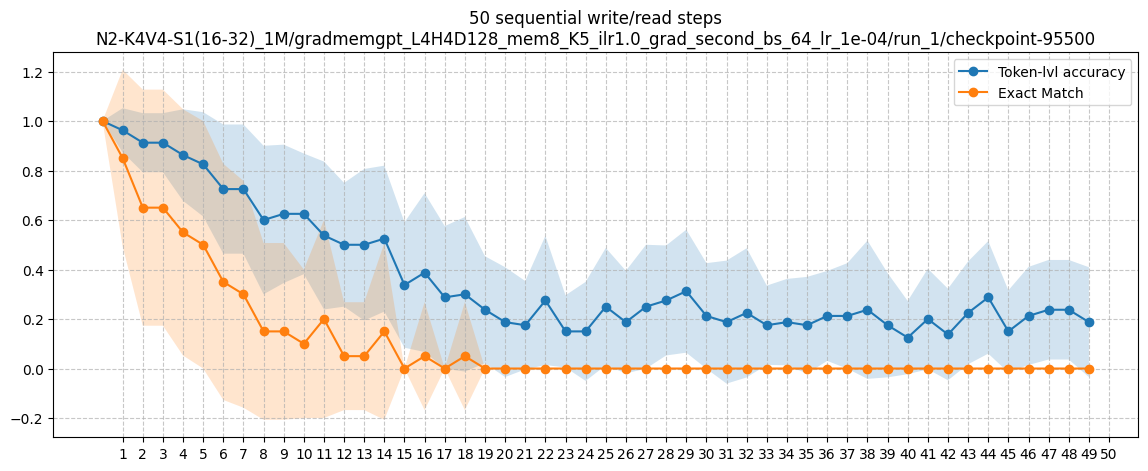

In [13]:
# plot accuracies, exact_matches
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

# Calculate means and standard deviations
acc_mean = accuracies.mean(axis=1)
acc_std = accuracies.std(axis=1)
exact_mean = exact_matches.mean(axis=1)
exact_std = exact_matches.std(axis=1)

# Plot means with shaded standard deviation regions
plt.plot(acc_mean, label='Token-lvl accuracy', marker='o')
plt.fill_between(range(len(acc_mean)), 
                 acc_mean - acc_std, 
                 acc_mean + acc_std, 
                 alpha=0.2)

plt.plot(exact_mean, label='Exact Match', marker='o')
plt.fill_between(range(len(exact_mean)), 
                 exact_mean - exact_std, 
                 exact_mean + exact_std, 
                 alpha=0.2)

# Add grid and show all x-axis values
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1,len(acc_mean)+1))  # Show all x-axis values

plt.title(f'{cl_steps} sequential write/read steps\n'
    f'{exp_path.relative_to(exp_path.parents[2])/checkpoint}')
plt.legend()
plt.show()


Generate

In [43]:
load_model(model, exp_path / checkpoint / 'model.safetensors')
model.eval()
model.cuda()
init_mem = model.mem.data.clone().detach()
init_lr = model.lr
model.lr = exp_config['inner_lr'] / exp_config['total_batch_size']
model.lr

0.015625

In [44]:
for batch in dataloader:
    print(batch)
    break

{'input_ids': {'context_input_ids': tensor([[56, 46, 66, 39, 23, 63, 56, 68, 40,  9, 62, 31, 66, 17, 40, 66, 15, 56,
         36, 43, 68, 53, 62,  9, 35, 66, 69,  0,  0,  0,  0,  0]]), 'query_input_ids': tensor([[67, 66, 39, 23, 63, 56, 68, 40,  9, 62, 31, 66, 69,  0,  0,  0]]), 'only_query_input_ids': tensor([[67, 66, 39, 23, 63, 56, 68]])}, 'labels': tensor([[-100, -100, -100, -100, -100, -100, -100,   40,    9,   62,   31,   66,
           69, -100, -100, -100]])}


In [45]:
# write
batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
batch['input_ids']['only_query_input_ids'] = batch['input_ids']['only_query_input_ids'].to('cuda')
batch['labels'] = batch['labels'].to('cuda')

outputs = model(**batch, return_mem=True)

In [46]:
mem_batch = outputs['mem'].detach()
mem_batch.shape

torch.Size([1, 8, 128])

In [56]:
qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

x_qry = torch.cat([mem_batch, qry_emb], dim=1)
gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

print(tokenizer.decode(batch['input_ids']['context_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
print(tokenizer.decode(batch['input_ids']['query_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

0Q!Jt70:Kf6B!nK!l0GN:X6fF!|
?!Jt70:Kf6B!|
Kf6B!|!|!|!|!|!|!|!|


In [57]:
qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

x_qry = torch.cat([mem_batch], dim=1)
gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

print(tokenizer.decode(batch['input_ids']['context_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
print(tokenizer.decode(batch['input_ids']['query_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

0Q!Jt70:Kf6B!nK!l0GN:X6fF!|
?!Jt70:Kf6B!|
!!!!!!!!!!!!!!!!!!!!


In [60]:
for batch in dataloader:
   
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['input_ids']['only_query_input_ids'] = batch['input_ids']['only_query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')
    
    # write
    with torch.no_grad():
        outputs = model(**batch, return_mem=True)
        mem_batch = outputs['mem'].detach()

        qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

        x_qry = torch.cat([mem_batch, qry_emb], dim=1)
        gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

        print(tokenizer.decode(batch['input_ids']['context_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
        print(tokenizer.decode(batch['input_ids']['query_input_ids'][0], skip_special_tokens=True).replace(' ', ''))

        print('generate from [mem][query]:')
        print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

        qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

        x_qry = torch.cat([mem_batch], dim=1)
        gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

        print('\ngenerate from [mem]:')
        print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

        print('-' * 100)

!dGCA:TNhf!!W0H5:PCyS!|
?!dGCA:TNhf!|
generate from [mem][query]:
TNhf!|!|!|!|!|!|!|!|

generate from [mem]:
!!!!!!!!!!!!!!!!!!!!
----------------------------------------------------------------------------------------------------
!mOgT:B1DE!vSf9!ulcu:IrpD!qak|
?!ulcu:IrpD!|
generate from [mem][query]:
IrpD!|!|!|!|!|!|!|!|

generate from [mem]:
!!!!!!!!!!!!!!!!!!!!
----------------------------------------------------------------------------------------------------
!2vxM:SDzZ!yvz0zP!67fV:HqGz!|
?!2vxM:SDzZ!|
generate from [mem][query]:
SDzZ!|!|!|!|!|!|!|!|

generate from [mem]:
!!!!!!!!!!!!!!!!!!!!
----------------------------------------------------------------------------------------------------
Hn!a7Gt:8a40!!oMUL:nrJl!c|
?!a7Gt:8a40!|
generate from [mem][query]:
8a40!|!|!|!|!|!|!|!|

generate from [mem]:
!!!!!!!!!!!!!!!!!!!!
----------------------------------------------------------------------------------------------------
sQ!SFr4:tG1x!L!nPf7:GKDY!1183|
?!nPf7:GKDY!|
generate from [

KeyboardInterrupt: 

In [172]:
sample = {'context': 'AAAADDDD!BBBB:YYYY!EEEECCCC|',
          #'context': 'DDDD!AAAA:XXXX!CCCC!BBBB:YYYY!|',
          'query': '?!BBBB:',
          'target': ''
          }
batch = collate_fn([sample], tokenizer)

batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
batch['input_ids']['only_query_input_ids'] = batch['input_ids']['only_query_input_ids'].to('cuda')
batch['labels'] = batch['labels'].to('cuda')

# write
with torch.no_grad():
    outputs = model(**batch, return_mem=True)
    mem_batch = outputs['mem'].detach()

    qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

    x_qry = torch.cat([mem_batch, qry_emb], dim=1)
    gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

    print(tokenizer.decode(batch['input_ids']['context_input_ids'][0], skip_special_tokens=True).replace(' ', ''))
    print(tokenizer.decode(batch['input_ids']['query_input_ids'][0], skip_special_tokens=True).replace(' ', ''))

    print('generate from [mem][query]:')
    print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

    qry_emb = model.model.transformer.wte(batch['input_ids']['only_query_input_ids'])

    x_qry = torch.cat([mem_batch], dim=1)
    gen_output = model.model.generate(inputs_embeds=x_qry, max_new_tokens=20)

    print('\ngenerate from [mem]:')
    print(tokenizer.decode(gen_output[0], skip_special_tokens=True).replace(' ', ''))

    print('-' * 100)

AAAADDDD!BBBB:YYYY!EEEECCCC|
?!BBBB:
generate from [mem][query]:
YYYY!|!|!|!|!|!|!|!|

generate from [mem]:
!!!!!!!!!!!!!!!!!!!!
----------------------------------------------------------------------------------------------------


In [ ]:
# check how inner loss changes if we change parts of input sequence after mem is ready
# generate always outputs !, so we got no useful info -- only that mem has not memorized full input
# 

In [242]:
import torch.nn as nn

sample = {'context': 'AAAADDDD!BBBB:YYYY!EEEECCCC|',
          #'context': 'DDDD!AAAA:XXXX!CCCC!BBBB:YYYY!|',
          'query': '?!BBBB:',
          'target': ''
          }
batch = collate_fn([sample], tokenizer)

batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
batch['input_ids']['only_query_input_ids'] = batch['input_ids']['only_query_input_ids'].to('cuda')
batch['labels'] = batch['labels'].to('cuda')

context_input_ids = batch['input_ids']['context_input_ids']
pad_id = model.model.config.pad_token_id

with torch.no_grad():
    # write
    outputs = model(**batch, return_mem=True)
    mem_batch = outputs['mem'].detach()

    # check inner loss
    ctx_emb = model.model.transformer.wte(context_input_ids)
    x_ctx = torch.cat([mem_batch, ctx_emb], dim=1)
    logits = model.model(inputs_embeds=x_ctx).logits
    logits = logits[:, model.n_mem_tokens+model.n_ctrl_tokens:, :]
    # shift‑left LM loss, ignore mem tokens + padding
    lm_labels = context_input_ids.clone()
    lm_labels[lm_labels == pad_id] = -100
    inner_loss = nn.functional.cross_entropy(
        logits[:, :-1].reshape(-1, logits.size(-1)),
        lm_labels[:, 1:].reshape(-1),
        ignore_index=-100,
    )

    print(f'inner_loss: {inner_loss:.4f}')

inner_loss: 5.8898


In [175]:
context_input_ids

tensor([[30, 30, 30, 30, 33, 33, 33, 33, 66, 31, 31, 31, 31, 68, 54, 54, 54, 54,
         66, 34, 34, 34, 34, 32, 32, 32, 32, 69,  0,  0,  0,  0]],
       device='cuda:0')

In [ ]:
noise; special; key; value;

In [211]:
def get_mask(s):
    """
    0 - special tokens (|!:)
    1 - noise tokens
    2 - key tokens
    3 - value tokens

    AAAA|DDDD!BBBB:YYYY!EEEE!TTTT:ZZZZ!CCCC|
    ->
    1111011110222203333011110222203333011110
    """
    mask = ''
    i = 0
    while i < len(s):
        if s[i] in '|!:':
            mask += 's'
            i += 1
        else:
            # Look ahead to determine token type
            j = i
            while j < len(s) and s[j] not in '|!:':
                j += 1
            
            # Check if this segment ends with : or !
            if j < len(s):
                if s[j] == ':':
                    # This is a key
                    while i < j:
                        mask += 'k'
                        i += 1
                elif s[j] == '!':
                    # Check if this is a value (preceded by :) or noise
                    if i > 0 and s[i-1] == ':':
                        while i < j:
                            mask +='v'
                            i += 1
                    else:
                        while i < j:
                            mask += 'n'
                            i += 1
                else:
                    # This is noise
                    while i < j:
                        mask += 'n'
                        i += 1
            else:
                # End of string, treat as noise
                while i < j:
                    mask += 'n'
                    i += 1
    return mask


In [212]:
print(get_mask('AAAA|DDDD!BBBB:YYYY!EEEE!TTTT:ZZZZ!CCCC|'))

nnnnsnnnnskkkksvvvvsnnnnskkkksvvvvsnnnns


make random permutation in context and check how inner loss is changed, collect stats for k, v, and noise tokens

In [270]:
import random
exclude_tokens = [':', '!', '|', '?', '[BOS]', '[EOS]', '[UNK]', '[PAD]']
exc_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in exclude_tokens]
to_sample_token_ids = [i for i in range(tokenizer.vocab_size) if i not in exc_token_ids]

loss_diffs = {
    'k': [],
    'v': [],
    'n': []
}

for batch in tqdm(dataloader):
    batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
    batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
    batch['input_ids']['only_query_input_ids'] = batch['input_ids']['only_query_input_ids'].to('cuda')
    batch['labels'] = batch['labels'].to('cuda')

    context_input_ids = batch['input_ids']['context_input_ids'].clone()
    pad_id = model.model.config.pad_token_id

    with torch.no_grad():
        # write
        outputs = model(**batch, return_mem=True)
        mem_batch = outputs['mem'].detach()

        # check inner loss with original context
        ctx_emb = model.model.transformer.wte(context_input_ids)
        x_ctx = torch.cat([mem_batch, ctx_emb], dim=1)
        logits = model.model(inputs_embeds=x_ctx).logits
        logits = logits[:, model.n_mem_tokens+model.n_ctrl_tokens:, :]
        # shift‑left LM loss, ignore mem tokens + padding
        lm_labels = context_input_ids.clone()
        lm_labels[lm_labels == pad_id] = -100
        inner_loss_orig = nn.functional.cross_entropy(
            logits[:, :-1].reshape(-1, logits.size(-1)),
            lm_labels[:, 1:].reshape(-1),
            ignore_index=-100,
        )

        context = tokenizer.decode(context_input_ids[0], skip_special_tokens=True).replace(' ', '')
        # print(context)
        token_type_mask = get_mask(context)
        for i, t in enumerate(token_type_mask):
            # replace token with ra
            if t != 's':
                new_context_input_ids = context_input_ids.clone()
                new_context_input_ids[0, i] = torch.tensor([random.choice(to_sample_token_ids)], device=context_input_ids.device)
                # print(tokenizer.decode(new_context_input_ids[0], skip_special_tokens=True).replace(' ', ''))
                
                # check inner loss with modified context
                ctx_emb = model.model.transformer.wte(new_context_input_ids)
                x_ctx = torch.cat([mem_batch, ctx_emb], dim=1)
                logits = model.model(inputs_embeds=x_ctx).logits
                logits = logits[:, model.n_mem_tokens+model.n_ctrl_tokens:, :]
                # shift‑left LM loss, ignore mem tokens + padding
                lm_labels = new_context_input_ids.clone()
                lm_labels[lm_labels == pad_id] = -100
                inner_loss = nn.functional.cross_entropy(
                    logits[:, :-1].reshape(-1, logits.size(-1)),
                    lm_labels[:, 1:].reshape(-1),
                    ignore_index=-100,
                )
                loss_diffs[t] += [(inner_loss.item() - inner_loss_orig.item()) / inner_loss_orig.item()]
            else:
                continue

100%|██████████| 5000/5000 [14:09<00:00,  5.88it/s]


<Figure size 400x600 with 0 Axes>

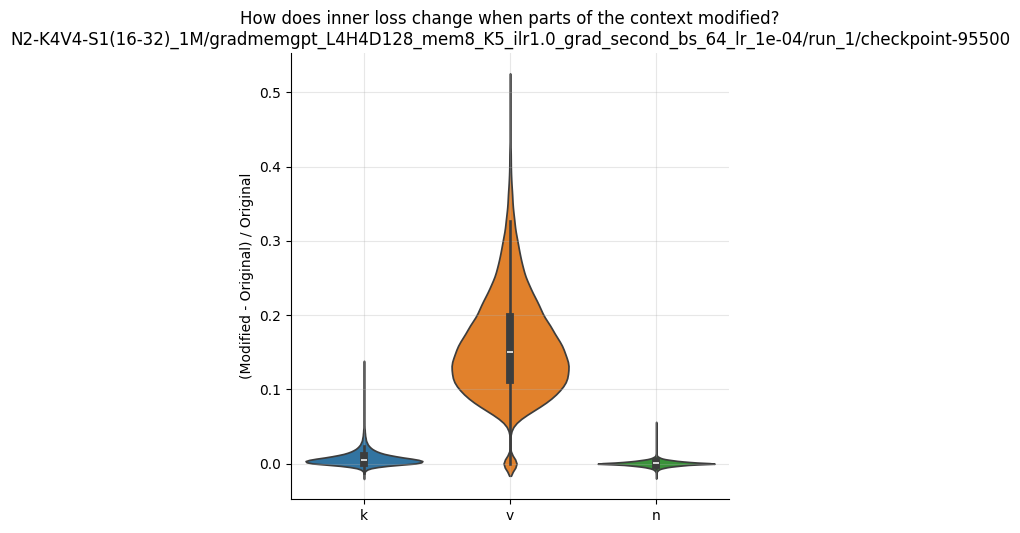

In [277]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 6))
sns.catplot(data=loss_diffs, kind='violin')
plt.title(f'How does inner loss change when parts of the context modified?\n{exp_path.relative_to(exp_path.parents[2])/checkpoint}')
plt.ylabel('(Modified - Original) / Original')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
ABCDEDF K:V  XXXYYYY K2:V2


EDF -> V

XXYY -> V2